Move from “object = solid block” to “object = identifiable 1D pattern.”

In [262]:
from pathlib import Path
import sys

from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    if "IPython.extensions.autoreload" not in ip.extension_manager.loaded:
        ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "lif_utils.py").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import torch
import pandas as pd
import matplotlib.pyplot as plt
from src import lif_utils as lu




SUCCESS HERE

In [212]:
patterns = {
    "A": torch.tensor([1, 0, 1, 1, 0, 1]),
    "B": torch.tensor([1, 1, 0, 0, 1, 1]),
    "C": torch.tensor([1, 0, 0, 1, 1, 1]),
    "D": torch.tensor([1, 1, 1, 0, 0, 1]),
}

length = 32
steps = 10
edge = "right"
speed = 6
intensity = 0.30

buffer_size = 4
beta = 0.9
delay = buffer_size - 1

In [213]:
pattern_name = "A"
pattern = patterns[pattern_name]

result = lu.run_pattern_pipeline(
    pattern_name=pattern_name,
    pattern=pattern,
    patterns=patterns,
    length=length,
    steps=steps,
    edge=edge,
    speed=speed,
    intensity=intensity,
    buffer_size=buffer_size,
    beta=beta,
)

print("pattern:", result["pattern_name"])
print("true speed:", speed if edge == "left" else -speed)
print("estimated speed:", result["estimated_speed"])
print("delay:", result["delay"])
print("full observations:")
for obs in result["full_observations"]:
    print(obs)

pattern: A
true speed: -6
estimated speed: -6
delay: 3
full observations:
{'time': 3, 'label': 'A', 'origin': 26, 'positions': [26, 28, 29, 31], 'compact': [1, 0, 1, 1, 0, 1], 'score': 1.0}
{'time': 4, 'label': 'A', 'origin': 20, 'positions': [20, 22, 23, 25], 'compact': [1, 0, 1, 1, 0, 1], 'score': 1.0}
{'time': 5, 'label': 'A', 'origin': 14, 'positions': [14, 16, 17, 19], 'compact': [1, 0, 1, 1, 0, 1], 'score': 1.0}
{'time': 6, 'label': 'A', 'origin': 8, 'positions': [8, 10, 11, 13], 'compact': [1, 0, 1, 1, 0, 1], 'score': 1.0}
{'time': 7, 'label': 'A', 'origin': 2, 'positions': [2, 4, 5, 7], 'compact': [1, 0, 1, 1, 0, 1], 'score': 1.0}


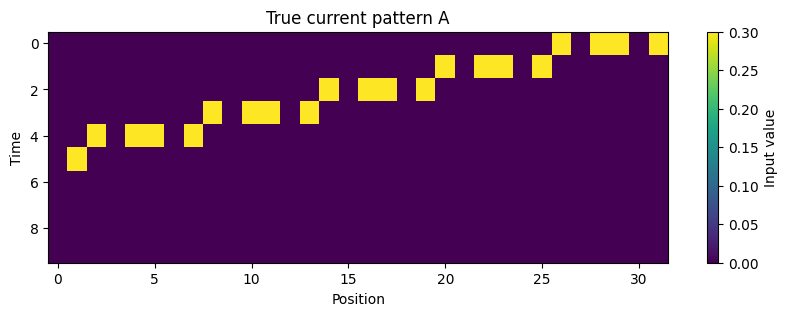

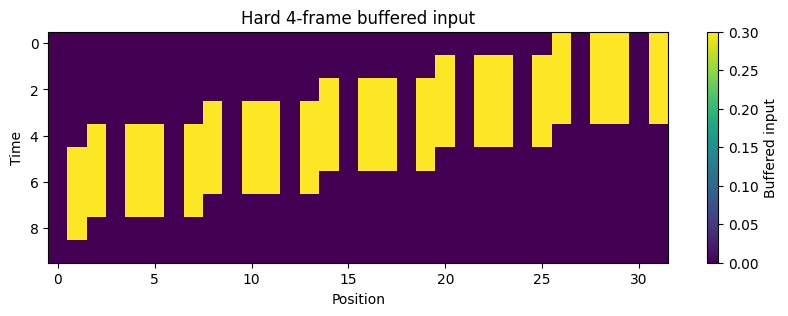

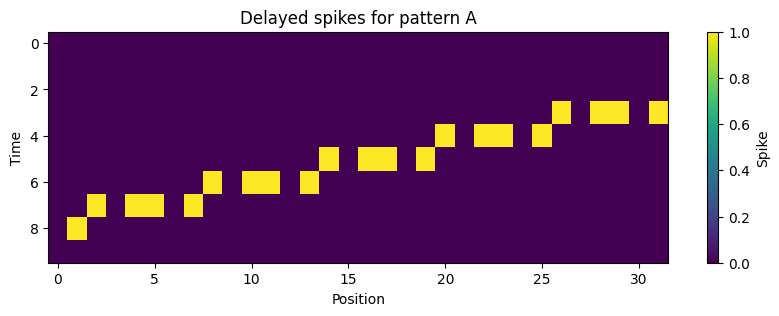

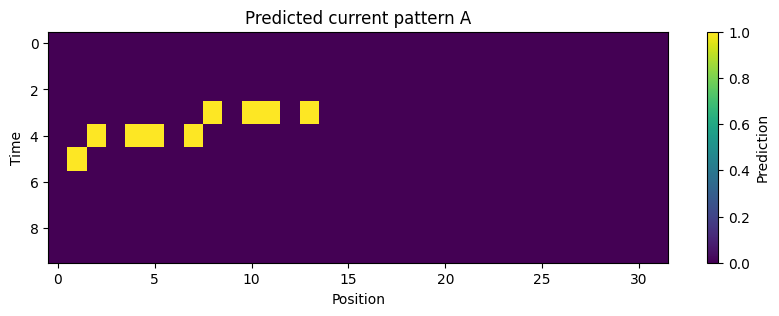

In [214]:
lu.plot_frame_matrix(
    result["frames"],
    title=f"True current pattern {pattern_name}",
    colorbar_label="Input value",
)

lu.plot_frame_matrix(
    result["buffered"],
    title=f"Hard {buffer_size}-frame buffered input",
    colorbar_label="Buffered input",
)

lu.plot_spikes(
    result["spk_rec"],
    f"Delayed spikes for pattern {pattern_name}",
)

lu.plot_frame_matrix(
    result["predicted_matrix"],
    title=f"Predicted current pattern {pattern_name}",
    colorbar_label="Prediction",
    vmin=0,
    vmax=1,
)

In [215]:
lu.print_pattern_position_comparison(result, patterns)

PATTERN: A
template: [1, 0, 1, 1, 0, 1]
estimated speed: -6
delay: 3
t=0
true positions:       [26, 28, 29, 31]
spike positions:      []
predicted positions:  []
exact match:          False
true compact:         [1, 0, 1, 1, 0, 1]
spike compact:        None
pred compact:         None
spike classified as:  unknown {}
pred classified as:   unknown {}
------------------------------------------------------------------------------------------
t=1
true positions:       [20, 22, 23, 25]
spike positions:      []
predicted positions:  []
exact match:          False
true compact:         [1, 0, 1, 1, 0, 1]
spike compact:        None
pred compact:         None
spike classified as:  unknown {}
pred classified as:   unknown {}
------------------------------------------------------------------------------------------
t=2
true positions:       [14, 16, 17, 19]
spike positions:      []
predicted positions:  []
exact match:          False
true compact:         [1, 0, 1, 1, 0, 1]
spike compact:        N


PATTERN: A
estimated speed: -6
delay: 3


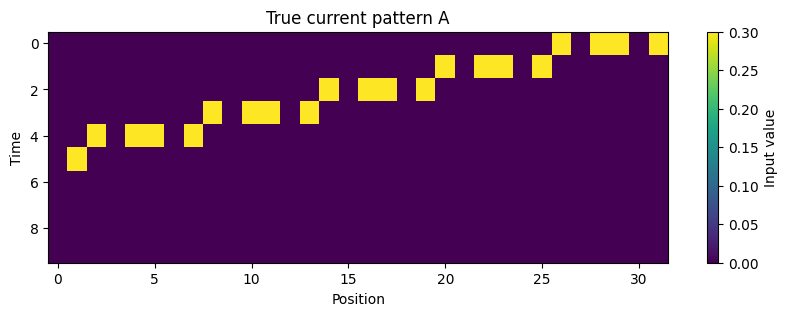

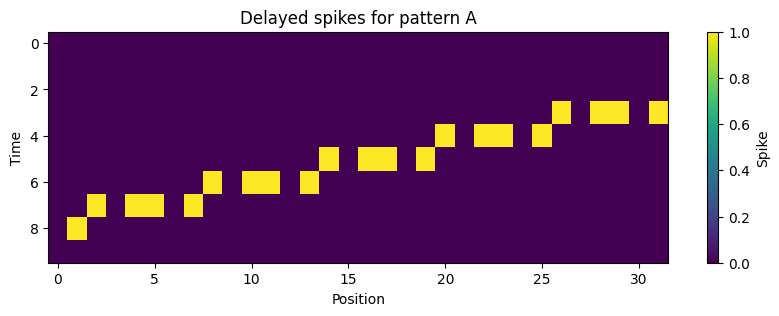

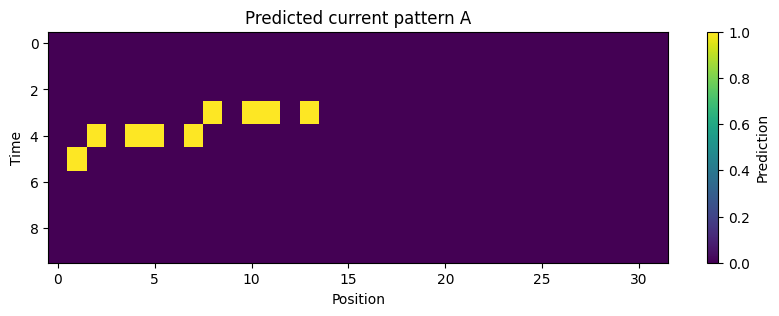


PATTERN: B
estimated speed: -6
delay: 3


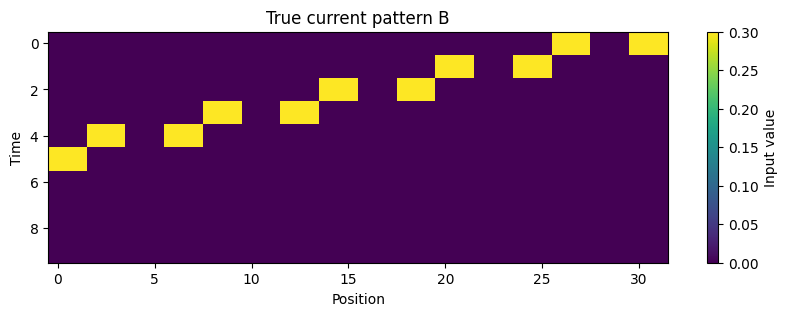

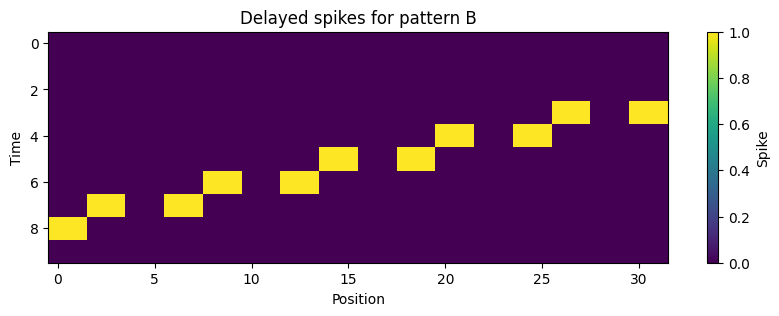

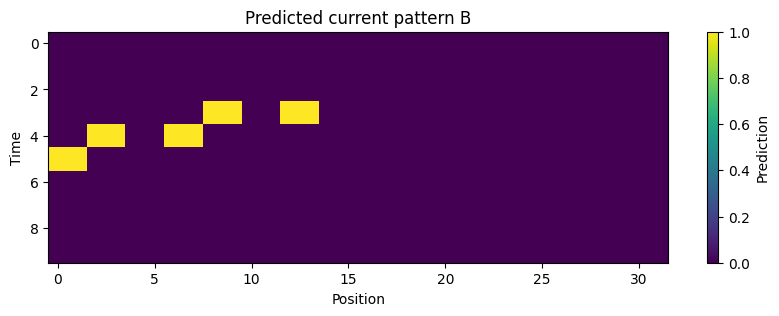


PATTERN: C
estimated speed: -6
delay: 3


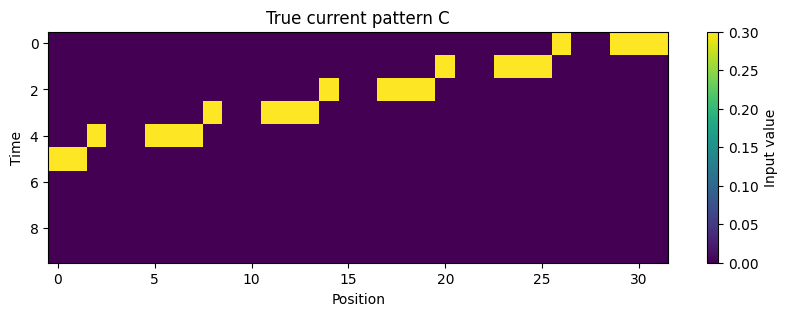

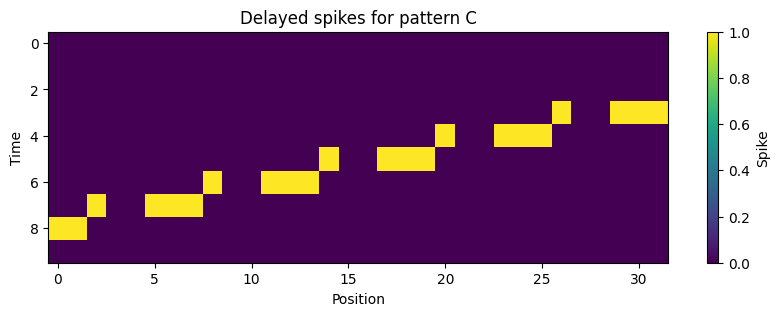

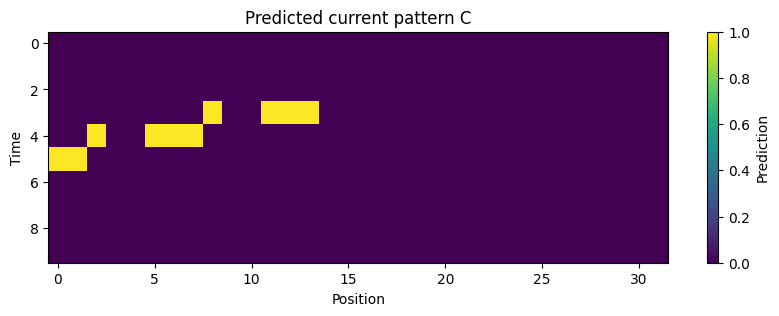


PATTERN: D
estimated speed: -6
delay: 3


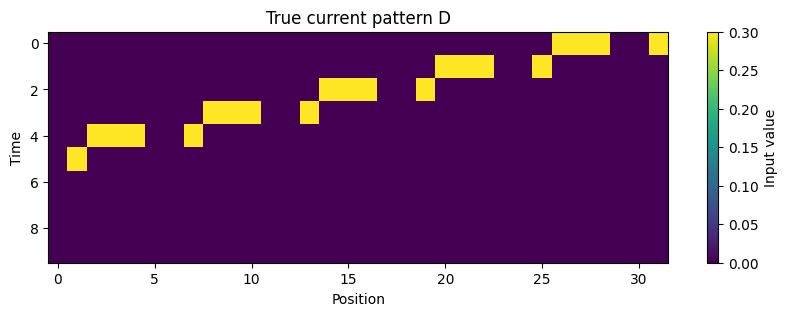

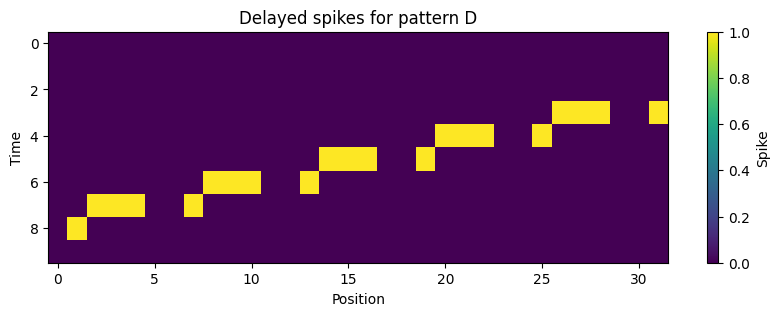

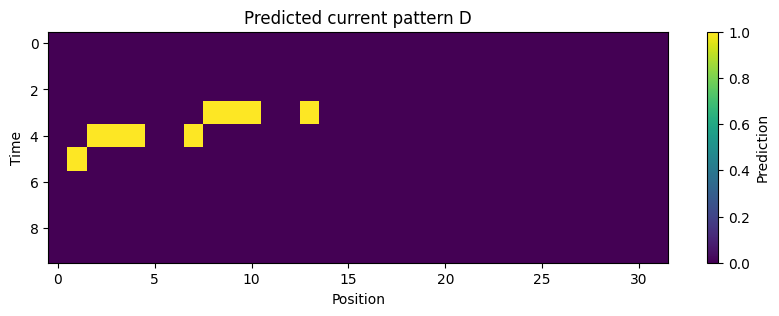

In [216]:
all_results = {}

for pattern_name, pattern in patterns.items():
    result = lu.run_pattern_pipeline(
        pattern_name=pattern_name,
        pattern=pattern,
        patterns=patterns,
        length=length,
        steps=steps,
        edge=edge,
        speed=speed,
        intensity=intensity,
        buffer_size=buffer_size,
        beta=beta,
    )

    all_results[pattern_name] = result

    print("\n" + "=" * 90)
    print("PATTERN:", pattern_name)
    print("estimated speed:", result["estimated_speed"])
    print("delay:", result["delay"])

    lu.plot_frame_matrix(
        result["frames"],
        title=f"True current pattern {pattern_name}",
        colorbar_label="Input value",
    )

    lu.plot_spikes(
        result["spk_rec"],
        f"Delayed spikes for pattern {pattern_name}",
    )

    lu.plot_frame_matrix(
        result["predicted_matrix"],
        title=f"Predicted current pattern {pattern_name}",
        colorbar_label="Prediction",
        vmin=0,
        vmax=1,
    )

In [217]:
summary_rows = []

for pattern_name, result in all_results.items():
    eval_result = lu.evaluate_pattern_result(result)

    summary_rows.append({
        "pattern": pattern_name,
        "estimated_speed": result["estimated_speed"],
        "delay": result["delay"],
        "num_exact_matches": eval_result["num_exact_matches"],
        "mean_coverage": eval_result["mean_coverage"],
        "mean_precision": eval_result["mean_precision"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,pattern,estimated_speed,delay,num_exact_matches,mean_coverage,mean_precision
0,A,-6,3,7,0.5,0.5
1,B,-6,3,7,0.5,0.5
2,C,-6,3,7,0.5,0.5
3,D,-6,3,7,0.5,0.5


This is a success, now I will try introducing varying velcoities

In [218]:
def make_moving_1d_pattern_from_edge_speed_schedule(
    pattern,
    length=64,
    steps=12,
    edge="left",
    speed_schedule=None,
    intensity=0.30,
):
    """
    Moving 1D pattern with changing speed.

    speed_schedule gives speed between frames:
        speed_schedule[0] moves t=0 -> t=1
        speed_schedule[1] moves t=1 -> t=2
        ...

    Speeds are positive magnitudes. Direction comes from edge.
    """
    pattern = pattern.clone().detach().float()

    if speed_schedule is None:
        speed_schedule = [len(pattern)] * (steps - 1)

    if len(speed_schedule) < steps - 1:
        last_speed = speed_schedule[-1]
        speed_schedule = speed_schedule + [last_speed] * (steps - 1 - len(speed_schedule))

    if edge == "left":
        pos = 0
        direction = 1
    elif edge == "right":
        pos = length - len(pattern)
        direction = -1
    else:
        raise ValueError("edge must be 'left' or 'right'")

    positions = [pos]

    for s in speed_schedule[:steps - 1]:
        pos = pos + direction * abs(s)
        positions.append(pos)

    frames = torch.zeros(steps, length)

    for t, pos in enumerate(positions):
        pos = int(round(pos))

        for i, value in enumerate(pattern):
            x = pos + i

            if 0 <= x < length and value > 0:
                frames[t, x] = intensity * value

    return frames, positions

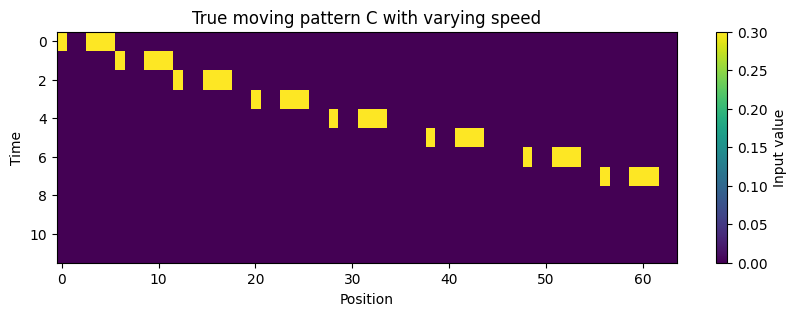

In [245]:
pattern_name = "C"
pattern = patterns[pattern_name]

length = 64
steps = 12
edge = "left"
speed_schedule = [6, 6, 8, 8, 10, 10, 8, 8, 6, 6, 6]

intensity = 0.30
buffer_size = 4
beta = 0.9
delay = buffer_size - 1

frames, true_origins = make_moving_1d_pattern_from_edge_speed_schedule(
    pattern=pattern,
    length=length,
    steps=steps,
    edge=edge,
    speed_schedule=speed_schedule,
    intensity=intensity,
)

lu.plot_frame_matrix(
    frames,
    title=f"True moving pattern {pattern_name} with varying speed",
    colorbar_label="Input value",
)

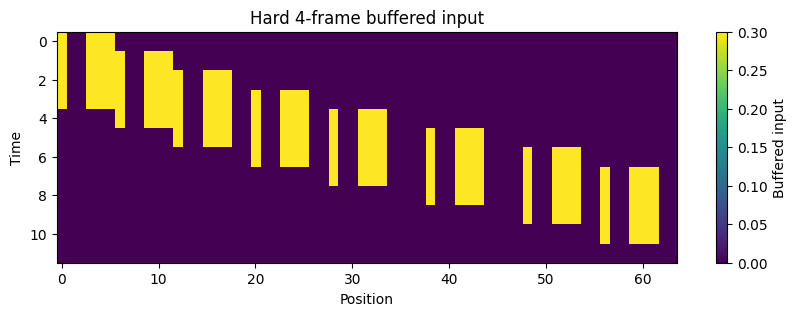

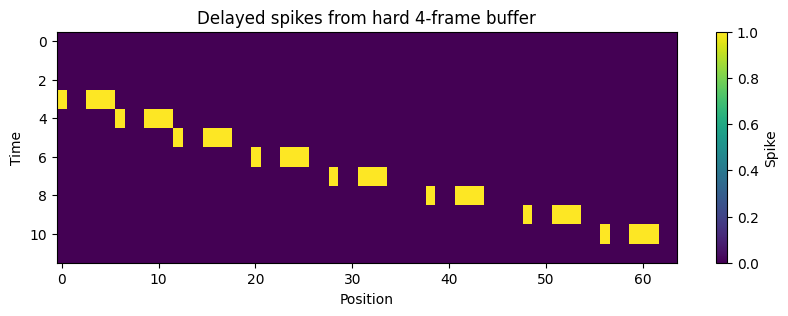

In [246]:
buffered = lu.apply_frame_buffer(
    frames,
    buffer_size=buffer_size,
)

spk_rec, mem_rec = lu.run_lif_layer(
    buffered,
    beta=beta,
)

spike_positions_by_time = lu.extract_spike_positions_by_time(
    spk_rec
)

lu.plot_frame_matrix(
    buffered,
    title="Hard 4-frame buffered input",
    colorbar_label="Buffered input",
)

lu.plot_spikes(
    spk_rec,
    "Delayed spikes from hard 4-frame buffer",
)

In [247]:
full_observations = lu.full_pattern_observations_from_spikes(
    spike_positions_by_time,
    pattern_templates=patterns,
    min_score=0.99,
)

for obs in full_observations:
    print(obs)

{'time': 3, 'label': 'C', 'origin': 0, 'positions': [0, 3, 4, 5], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 4, 'label': 'C', 'origin': 6, 'positions': [6, 9, 10, 11], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 5, 'label': 'C', 'origin': 12, 'positions': [12, 15, 16, 17], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 6, 'label': 'C', 'origin': 20, 'positions': [20, 23, 24, 25], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 7, 'label': 'C', 'origin': 28, 'positions': [28, 31, 32, 33], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 8, 'label': 'C', 'origin': 38, 'positions': [38, 41, 42, 43], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 9, 'label': 'C', 'origin': 48, 'positions': [48, 51, 52, 53], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 10, 'label': 'C', 'origin': 56, 'positions': [56, 59, 60, 61], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}


In [248]:
def estimate_local_speeds_from_full_observations(full_observations):
    """
    Adds local speed estimates between consecutive full-pattern observations.

    Returns list of dicts:
        time
        origin
        local_speed
        positions
        label
    """
    rows = []

    previous = None

    for obs in full_observations:
        if previous is None:
            local_speed = None
        else:
            dt = obs["time"] - previous["time"]
            dx = obs["origin"] - previous["origin"]

            if dt > 0:
                local_speed = dx / dt
            else:
                local_speed = None

        rows.append({
            "time": obs["time"],
            "origin": obs["origin"],
            "label": obs["label"],
            "positions": obs["positions"],
            "local_speed": local_speed,
        })

        previous = obs

    return rows

In [249]:
local_speed_rows = estimate_local_speeds_from_full_observations(
    full_observations
)

for row in local_speed_rows:
    print(row)

{'time': 3, 'origin': 0, 'label': 'C', 'positions': [0, 3, 4, 5], 'local_speed': None}
{'time': 4, 'origin': 6, 'label': 'C', 'positions': [6, 9, 10, 11], 'local_speed': 6.0}
{'time': 5, 'origin': 12, 'label': 'C', 'positions': [12, 15, 16, 17], 'local_speed': 6.0}
{'time': 6, 'origin': 20, 'label': 'C', 'positions': [20, 23, 24, 25], 'local_speed': 8.0}
{'time': 7, 'origin': 28, 'label': 'C', 'positions': [28, 31, 32, 33], 'local_speed': 8.0}
{'time': 8, 'origin': 38, 'label': 'C', 'positions': [38, 41, 42, 43], 'local_speed': 10.0}
{'time': 9, 'origin': 48, 'label': 'C', 'positions': [48, 51, 52, 53], 'local_speed': 10.0}
{'time': 10, 'origin': 56, 'label': 'C', 'positions': [56, 59, 60, 61], 'local_speed': 8.0}


In [250]:
def predict_current_positions_from_local_speeds(
    spike_positions_by_time,
    local_speed_rows,
    delay,
    length,
):
    predicted_positions_by_time = [
        [] for _ in spike_positions_by_time
    ]

    for row in local_speed_rows:
        t = row["time"]
        local_speed = row["local_speed"]

        if local_speed is None:
            continue

        shift = int(round(local_speed * delay))

        predicted_positions_by_time[t] = lu.shift_positions(
            row["positions"],
            shift=shift,
            length=length,
        )

    return predicted_positions_by_time

In [251]:
predicted_positions_by_time = predict_current_positions_from_local_speeds(
    spike_positions_by_time=spike_positions_by_time,
    local_speed_rows=local_speed_rows,
    delay=delay,
    length=length,
)

predicted_matrix = lu.positions_by_time_to_matrix(
    predicted_positions_by_time,
    length=length,
)

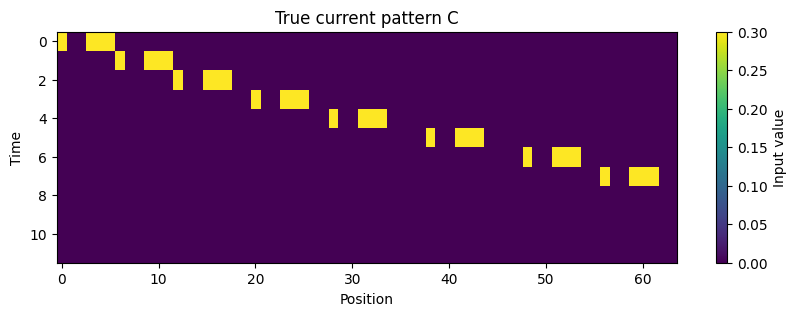

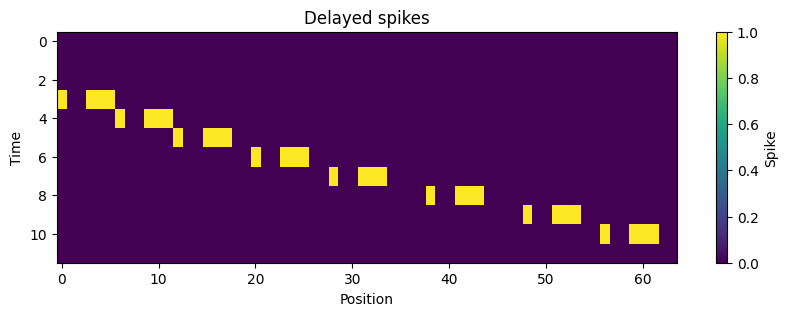

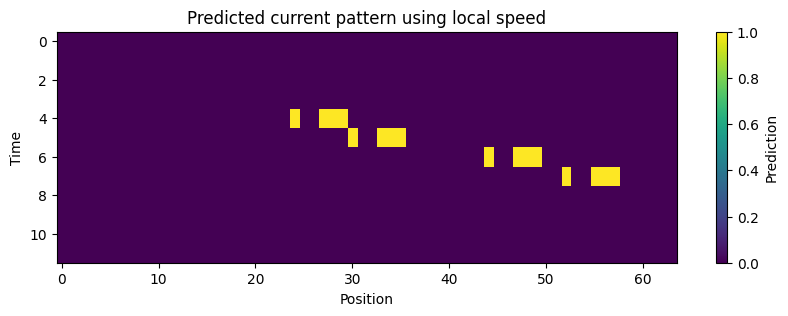

In [252]:
lu.plot_frame_matrix(
    frames,
    title=f"True current pattern {pattern_name}",
    colorbar_label="Input value",
)

lu.plot_spikes(
    spk_rec,
    "Delayed spikes",
)

lu.plot_frame_matrix(
    predicted_matrix,
    title="Predicted current pattern using local speed",
    colorbar_label="Prediction",
    vmin=0,
    vmax=1,
)

In [253]:
for t in range(frames.shape[0]):
    true_positions = torch.where(frames[t] > 0)[0].tolist()
    spike_positions = spike_positions_by_time[t]
    predicted_positions = predicted_positions_by_time[t]

    print(f"t={t}")
    print("true origin:", true_origins[t])
    print("true positions:     ", true_positions)
    print("spike positions:    ", spike_positions)
    print("predicted positions:", predicted_positions)
    print("exact match:        ", set(true_positions) == set(predicted_positions))
    print()

t=0
true origin: 0
true positions:      [0, 3, 4, 5]
spike positions:     []
predicted positions: []
exact match:         False

t=1
true origin: 6
true positions:      [6, 9, 10, 11]
spike positions:     []
predicted positions: []
exact match:         False

t=2
true origin: 12
true positions:      [12, 15, 16, 17]
spike positions:     []
predicted positions: []
exact match:         False

t=3
true origin: 20
true positions:      [20, 23, 24, 25]
spike positions:     [0, 3, 4, 5]
predicted positions: []
exact match:         False

t=4
true origin: 28
true positions:      [28, 31, 32, 33]
spike positions:     [6, 9, 10, 11]
predicted positions: [24, 27, 28, 29]
exact match:         False

t=5
true origin: 38
true positions:      [38, 41, 42, 43]
spike positions:     [12, 15, 16, 17]
predicted positions: [30, 33, 34, 35]
exact match:         False

t=6
true origin: 48
true positions:      [48, 51, 52, 53]
spike positions:     [20, 23, 24, 25]
predicted positions: [44, 47, 48, 49]
exact 

This doesnt work, need a trajectory predictor

In [254]:
def active_offsets_from_template(template):
    return torch.where(template > 0)[0].tolist()

In [255]:
def clip_positions(positions, length):
    return sorted([
        int(pos)
        for pos in positions
        if 0 <= int(pos) < length
    ])

In [256]:
import numpy as np

def forecast_origin_from_delayed_observations(
    available_observations,
    current_time,
    delay,
    max_degree=1,
):
    """
    Forecast current origin from delayed trajectory observations.

    available_observations:
        observations available up to current_time.
        Each obs has:
            obs["time"]   = spike time
            obs["origin"] = delayed pattern origin

    delayed_time = obs["time"] - delay

    max_degree=1:
        constant-velocity linear forecast

    max_degree=2:
        acceleration-aware quadratic forecast
    """
    if len(available_observations) < 2:
        return None

    times = np.array(
        [obs["time"] - delay for obs in available_observations],
        dtype=float,
    )

    origins = np.array(
        [obs["origin"] for obs in available_observations],
        dtype=float,
    )

    degree = min(max_degree, len(available_observations) - 1)

    coeffs = np.polyfit(times, origins, degree)
    predicted_origin = np.polyval(coeffs, current_time)

    return int(round(predicted_origin))

In [257]:
def predict_current_positions_from_forecasted_trajectory(
    full_observations,
    pattern_templates,
    delay,
    length,
    steps,
    max_degree=1,
):
    """
    Predict current positions from full delayed pattern observations.

    Unlike local_speed * delay, this forecasts the trajectory from all
    delayed observations available so far.
    """
    predicted_positions_by_time = [[] for _ in range(steps)]
    forecasted_origins_by_time = [None for _ in range(steps)]

    for obs in full_observations:
        current_time = obs["time"]
        label = obs["label"]

        available = [
            prev_obs
            for prev_obs in full_observations
            if prev_obs["time"] <= current_time
            and prev_obs["label"] == label
        ]

        predicted_origin = forecast_origin_from_delayed_observations(
            available,
            current_time=current_time,
            delay=delay,
            max_degree=max_degree,
        )

        if predicted_origin is None:
            continue

        offsets = active_offsets_from_template(
            pattern_templates[label]
        )

        predicted_positions = [
            predicted_origin + offset
            for offset in offsets
        ]

        predicted_positions = clip_positions(
            predicted_positions,
            length=length,
        )

        predicted_positions_by_time[current_time] = predicted_positions
        forecasted_origins_by_time[current_time] = predicted_origin

    return predicted_positions_by_time, forecasted_origins_by_time

In [258]:
full_observations = lu.full_pattern_observations_from_spikes(
    spike_positions_by_time,
    pattern_templates=patterns,
    min_score=0.99,
)

for obs in full_observations:
    print(obs)

{'time': 3, 'label': 'C', 'origin': 0, 'positions': [0, 3, 4, 5], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 4, 'label': 'C', 'origin': 6, 'positions': [6, 9, 10, 11], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 5, 'label': 'C', 'origin': 12, 'positions': [12, 15, 16, 17], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 6, 'label': 'C', 'origin': 20, 'positions': [20, 23, 24, 25], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 7, 'label': 'C', 'origin': 28, 'positions': [28, 31, 32, 33], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 8, 'label': 'C', 'origin': 38, 'positions': [38, 41, 42, 43], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 9, 'label': 'C', 'origin': 48, 'positions': [48, 51, 52, 53], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}
{'time': 10, 'label': 'C', 'origin': 56, 'positions': [56, 59, 60, 61], 'compact': [1, 0, 0, 1, 1, 1], 'score': 1.0}


In [259]:
predicted_positions_linear, forecasted_origins_linear = (
    predict_current_positions_from_forecasted_trajectory(
        full_observations=full_observations,
        pattern_templates=patterns,
        delay=delay,
        length=length,
        steps=steps,
        max_degree=1,
    )
)

predicted_positions_quadratic, forecasted_origins_quadratic = (
    predict_current_positions_from_forecasted_trajectory(
        full_observations=full_observations,
        pattern_templates=patterns,
        delay=delay,
        length=length,
        steps=steps,
        max_degree=2,
    )
)

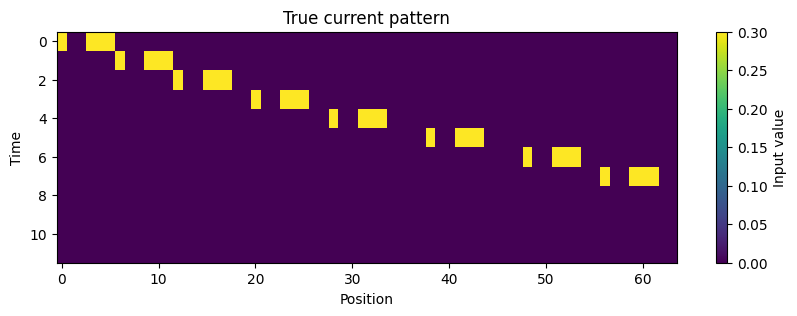

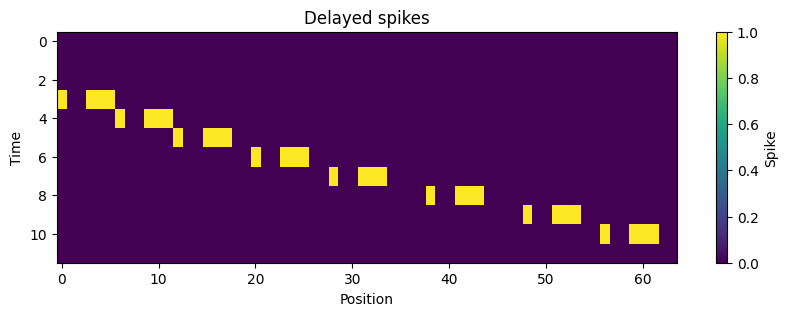

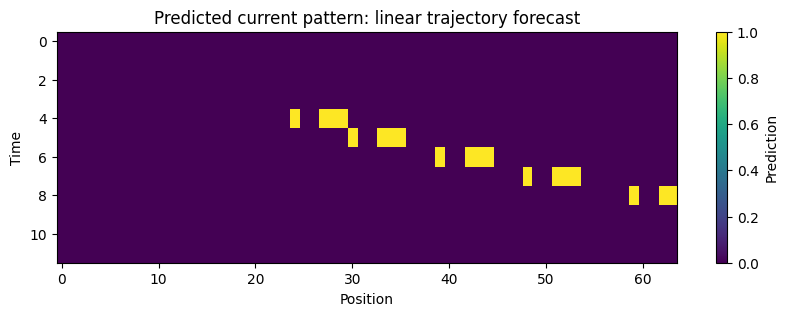

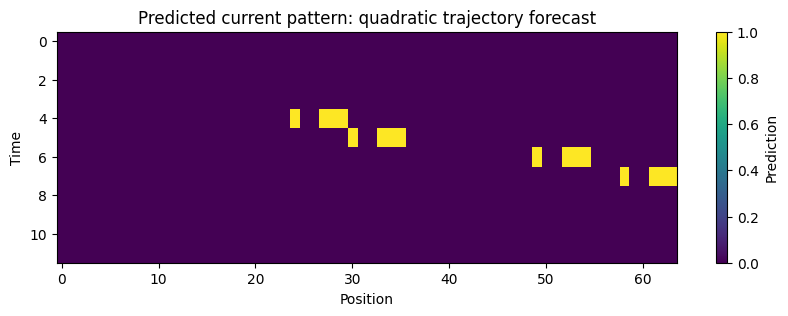

In [260]:
predicted_matrix_linear = lu.positions_by_time_to_matrix(
    predicted_positions_linear,
    length=length,
)

predicted_matrix_quadratic = lu.positions_by_time_to_matrix(
    predicted_positions_quadratic,
    length=length,
)

lu.plot_frame_matrix(
    frames,
    title="True current pattern",
    colorbar_label="Input value",
)

lu.plot_spikes(
    spk_rec,
    "Delayed spikes",
)

lu.plot_frame_matrix(
    predicted_matrix_linear,
    title="Predicted current pattern: linear trajectory forecast",
    colorbar_label="Prediction",
    vmin=0,
    vmax=1,
)

lu.plot_frame_matrix(
    predicted_matrix_quadratic,
    title="Predicted current pattern: quadratic trajectory forecast",
    colorbar_label="Prediction",
    vmin=0,
    vmax=1,
)

In [261]:
for t in range(frames.shape[0]):
    true_positions = torch.where(frames[t] > 0)[0].tolist()

    print(f"t={t}")
    print("true origin:              ", true_origins[t])
    print("true positions:           ", true_positions)
    print("spike positions:          ", spike_positions_by_time[t])
    print("linear forecast origin:   ", forecasted_origins_linear[t])
    print("linear predicted pos:     ", predicted_positions_linear[t])
    print("linear exact match:       ", set(true_positions) == set(predicted_positions_linear[t]))
    print("quadratic forecast origin:", forecasted_origins_quadratic[t])
    print("quadratic predicted pos:  ", predicted_positions_quadratic[t])
    print("quadratic exact match:    ", set(true_positions) == set(predicted_positions_quadratic[t]))
    print()

t=0
true origin:               0
true positions:            [0, 3, 4, 5]
spike positions:           []
linear forecast origin:    None
linear predicted pos:      []
linear exact match:        False
quadratic forecast origin: None
quadratic predicted pos:   []
quadratic exact match:     False

t=1
true origin:               6
true positions:            [6, 9, 10, 11]
spike positions:           []
linear forecast origin:    None
linear predicted pos:      []
linear exact match:        False
quadratic forecast origin: None
quadratic predicted pos:   []
quadratic exact match:     False

t=2
true origin:               12
true positions:            [12, 15, 16, 17]
spike positions:           []
linear forecast origin:    None
linear predicted pos:      []
linear exact match:        False
quadratic forecast origin: None
quadratic predicted pos:   []
quadratic exact match:     False

t=3
true origin:               20
true positions:            [20, 23, 24, 25]
spike positions:           [0, 3,